<a href="https://colab.research.google.com/github/KhushnurAnjum26/machine-Learning/blob/main/ML_Lab_Water.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from google.colab import files
from sklearn.preprocessing import MinMaxScaler

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, confusion_matrix, roc_curve

# XGBoost & LightGBM
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import GridSearchCV


In [2]:
df=pd.read_csv("water_potability.csv")
df.head(10)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


In [3]:
df.tail(10)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3266,8.372910,169.087052,14622.745494,7.547984,NaN,464.525552,11.083027,38.435151,4.906358,1
3267,8.989900,215.047358,15921.412018,6.297312,312.931022,390.410231,9.899115,55.069304,4.613843,1
3268,6.702547,207.321086,17246.920347,7.708117,304.510230,329.266002,16.217303,28.878601,3.442983,1
3269,11.491011,94.812545,37188.826022,9.263166,258.930600,439.893618,16.172755,41.558501,4.369264,1
3270,6.069616,186.659040,26138.780191,7.747547,345.700257,415.886955,12.067620,60.419921,3.669712,1
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


In [4]:
df.shape

(3276, 10)

In [5]:
print(df.dtypes)

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


In [6]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [7]:
df.isnull()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
3271,False,False,False,False,False,False,False,False,False,False
3272,False,False,False,False,True,False,False,True,False,False
3273,False,False,False,False,True,False,False,False,False,False
3274,False,False,False,False,True,False,False,False,False,False


In [8]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [9]:
# Fill numerical columns with median
df['ph'].fillna(df['ph'].mean(),inplace=True)
df['Sulfate'].fillna(df['Sulfate'].mean(),inplace=True)
df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean(),inplace=True)

In [14]:
df.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [15]:
df["Potability"].value_counts()


,count
Potability,
0,1998
1,1278


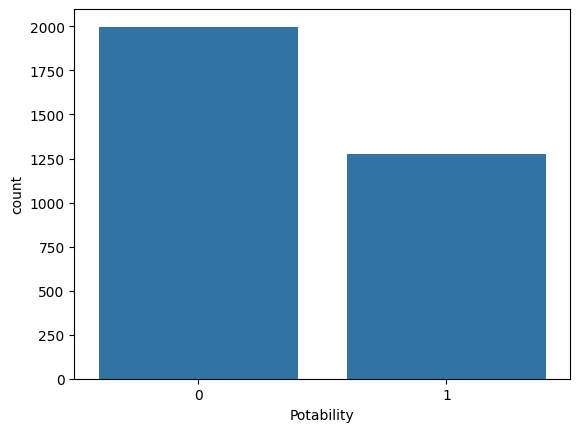

In [16]:
sns.countplot(x="Potability", data=df)
plt.show()


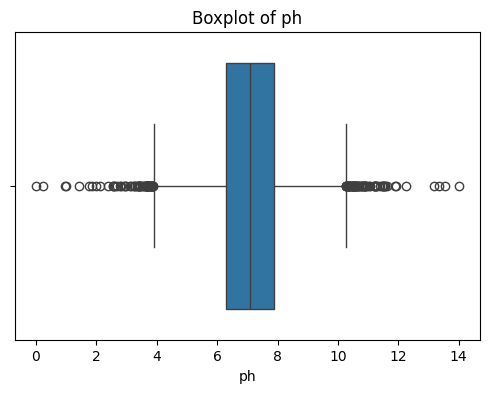

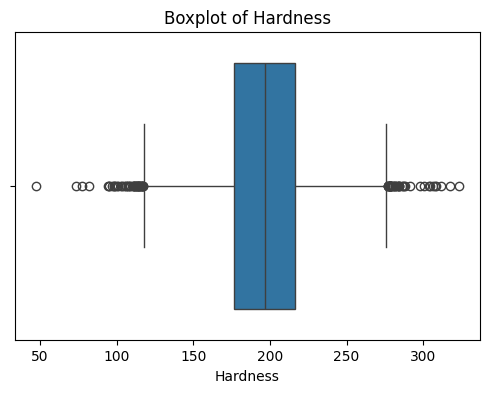

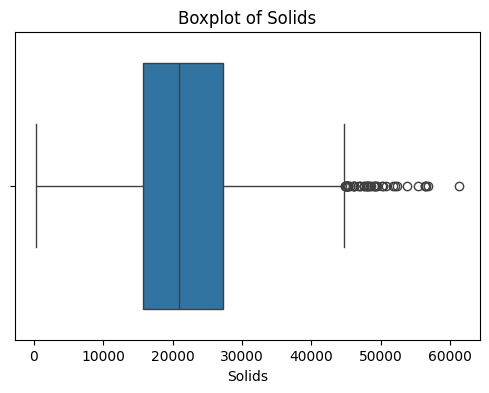

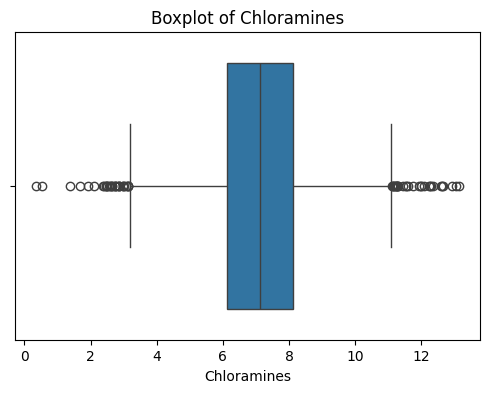

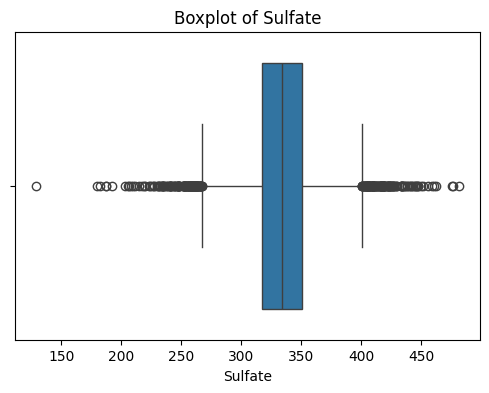

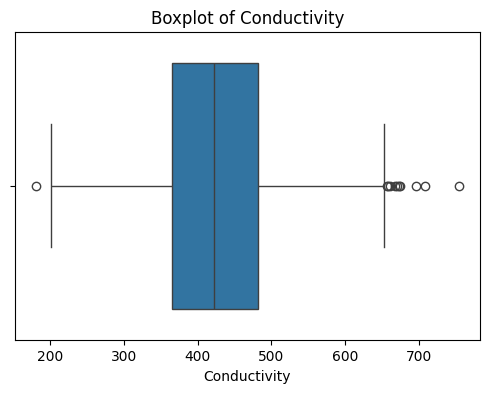

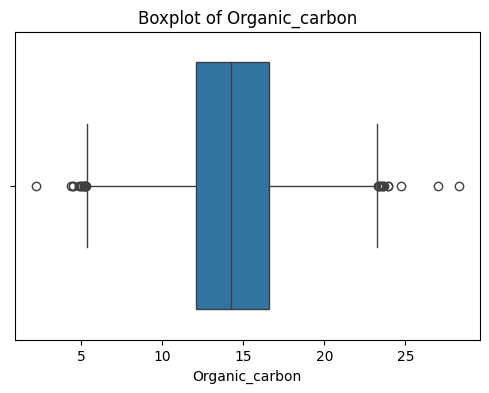

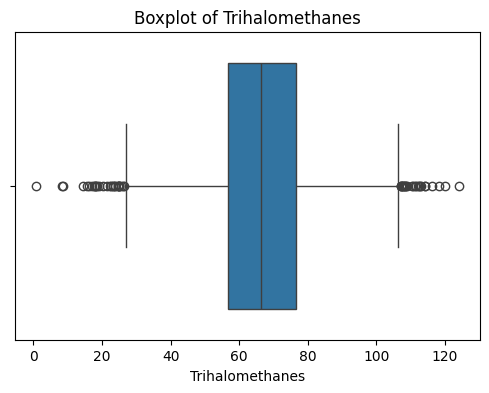

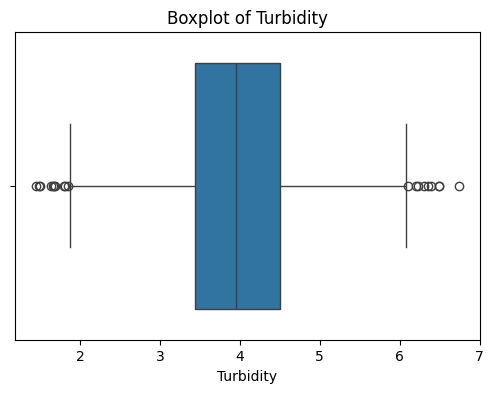

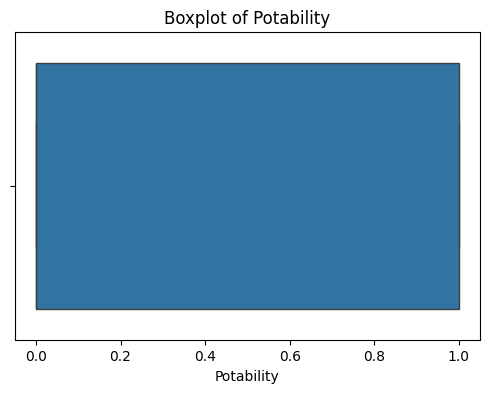

In [17]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Visualize using boxplots
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [18]:

# Detect outliers
# Select only numeric columns for outlier detection
num_cols = df.select_dtypes(include=[np.number]).columns
outliers_dict = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find indices of outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outliers_dict[col] = outliers
    print(f"{col} - Outliers detected: {len(outliers)}")

ph - Outliers detected: 142
Hardness - Outliers detected: 83
Solids - Outliers detected: 47
Chloramines - Outliers detected: 61
Sulfate - Outliers detected: 264
Conductivity - Outliers detected: 11
Organic_carbon - Outliers detected: 25
Trihalomethanes - Outliers detected: 54
Turbidity - Outliers detected: 19
Potability - Outliers detected: 0


In [19]:
# Combine all outlier indices from all columns
all_outliers = set()
for outlier_list in outliers_dict.values():
    all_outliers.update(outlier_list)
# Remove outliers from the dataset
df = df.drop(index=all_outliers).reset_index(drop=True)

print(f"Total rows after outlier removal: {len(df)}")


Total rows after outlier removal: 2666


In [20]:
#first copy orginal df
df_minmax=df.copy()

In [21]:
# Select only numeric columns
numeric_cols = df_minmax.select_dtypes(include=[np.number]).columns

# Apply Min-Max manually to each numeric column
for col in numeric_cols:
    col_min = np.min(df_minmax[col])
    col_max = np.max(df_minmax[col])
    df_minmax[col] = (df_minmax[col] - col_min) / (col_max - col_min)

# Show the result
print(df_minmax[numeric_cols].head())

         ph  Hardness    Solids  Chloramines   Sulfate  Conductivity  \
0  0.500496  0.547502  0.461758     0.520207  0.761347      0.804335   
1  0.660854  0.670803  0.441867     0.770560  0.500280      0.481211   
2  0.695127  0.607942  0.489438     0.616401  0.673948      0.358484   
3  0.817239  0.395881  0.398319     0.424711  0.322632      0.436423   
4  0.264806  0.441846  0.641255     0.551209  0.446945      0.174862   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0        0.280742         0.754090   0.258967         0.0  
1        0.643817         0.493079   0.281003         0.0  
2        0.731546         0.923489   0.654492         0.0  
3        0.346683         0.056319   0.523011         0.0  
4        0.169951         0.347135   0.163169         0.0  


In [22]:
df2=df.copy()

# Select only numeric columns
numeric_cols = df2.select_dtypes(include=[np.number]).columns

# Apply Z-score manually to each numeric column
for col in numeric_cols:
    mean = np.mean(df2[col])
    std = np.std(df2[col])
    df2[col] = (df2[col] - mean) / std

# Check the result
print(df2[numeric_cols].head())

         ph  Hardness    Solids  Chloramines   Sulfate  Conductivity  \
0  0.005967  0.276380 -0.087788     0.133760  1.311504      1.731801   
1  0.843882  0.958501 -0.199087     1.531834  0.000565     -0.090093   
2  1.022965  0.610743  0.067098     0.670947  0.872634     -0.782072   
3  1.661037 -0.562404 -0.442764    -0.399530 -0.891492     -0.342620   
4 -1.225574 -0.308120  0.916600     0.306890 -0.267256     -1.817403   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       -1.220488         1.379762  -1.312414   -0.771655  
1        0.796898        -0.001226  -1.190445   -0.771655  
2        1.284355         2.276037   0.876799   -0.771655  
3       -0.854093        -2.312089   0.149055   -0.771655  
4       -1.836085        -0.773406  -1.842654   -0.771655  


In [23]:
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
2,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
3,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
4,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
...,...,...,...,...,...,...,...,...,...,...
2661,6.069616,186.659040,26138.780191,7.747547,345.700257,415.886955,12.067620,60.419921,3.669712,1
2662,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
2663,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1
2664,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1


In [24]:
# Check for duplicates
duplicates = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicates.shape[0]}")

# Remove duplicate rows
df= df.drop_duplicates()

# Reset index (optional)
df.reset_index(drop=True, inplace=True)

# Check the result
print(df.head())

Number of duplicate rows: 0
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0  7.080795  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  8.099124  224.236259  19909.541732     9.275884  333.775777    418.606213   
2  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
3  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   
4  5.584087  188.313324  28748.687739     7.544869  326.678363    280.467916   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       16.868637        66.420093   3.055934           0  
2       18.436524       100.341674   4.628771           0  
3       11.558279        31.997993   4.075075           0  
4        8.399735        54.917862   2.559708           0  


In [25]:

# Initialize the scaler
scaler = MinMaxScaler()
# List of numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
# Apply Min-Max Scaling
df[num_cols] = scaler.fit_transform(df[num_cols])
print("Min-Max Scaling applied. Values are now between 0 and 1.")

Min-Max Scaling applied. Values are now between 0 and 1.


In [26]:
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,0.500496,0.547502,0.461758,0.520207,0.761347,0.804335,0.280742,0.754090,0.258967,0.0
1,0.660854,0.670803,0.441867,0.770560,0.500280,0.481211,0.643817,0.493079,0.281003,0.0
2,0.695127,0.607942,0.489438,0.616401,0.673948,0.358484,0.731546,0.923489,0.654492,0.0
3,0.817239,0.395881,0.398319,0.424711,0.322632,0.436423,0.346683,0.056319,0.523011,0.0
4,0.264806,0.441846,0.641255,0.551209,0.446945,0.174862,0.169951,0.347135,0.163169,0.0
...,...,...,...,...,...,...,...,...,...,...
2661,0.341264,0.431302,0.582382,0.576892,0.589889,0.475180,0.375183,0.416947,0.426752,1.0
2662,0.615145,0.475243,0.383675,0.616658,0.500280,0.423203,0.813613,0.492777,0.219812,1.0
2663,0.868778,0.361854,0.740663,0.526546,0.500280,0.511013,0.317632,0.536541,0.338693,1.0
2664,0.192791,0.711387,0.263085,0.393888,0.500280,0.446342,0.324899,0.633516,0.673463,1.0


In [27]:
 # Make a copy of numerical columns
 df_copy = df[num_cols].copy()
 # Apply log transformation safely
 df[num_cols] = np.log1p(df_copy)
 print("Log transformation applied to reduce skewness.")

Log transformation applied to reduce skewness.


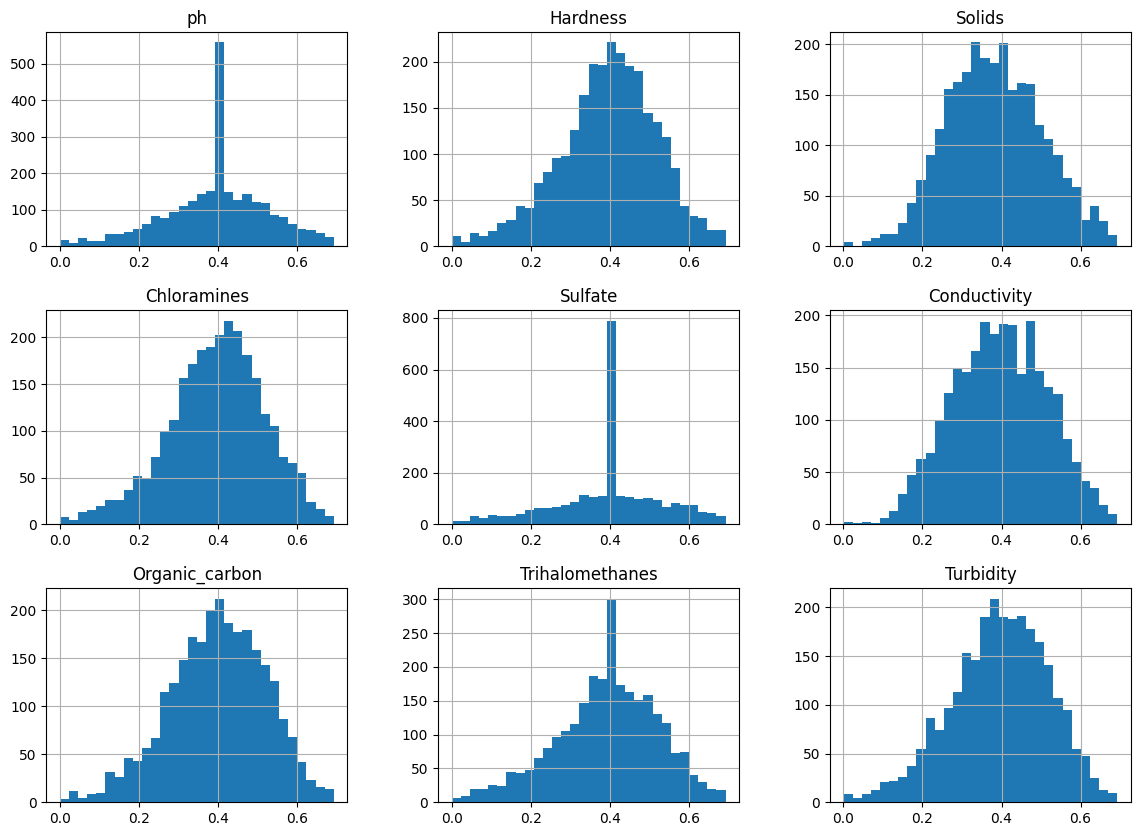

In [28]:
df.drop("Potability", axis=1).hist(figsize=(14,10), bins=30)
plt.show()


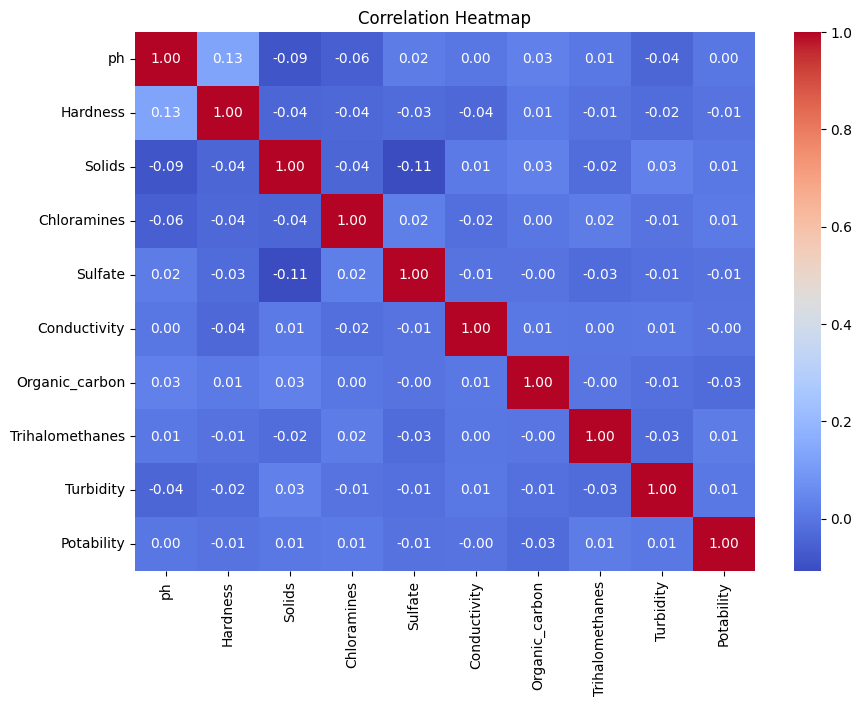

In [29]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


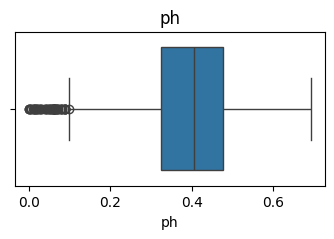

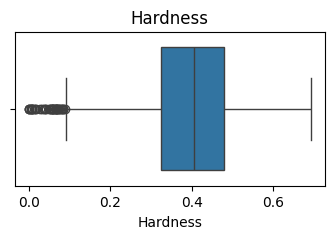

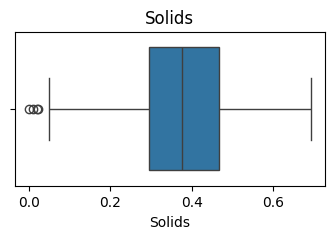

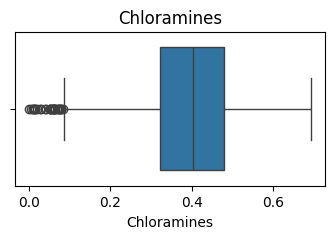

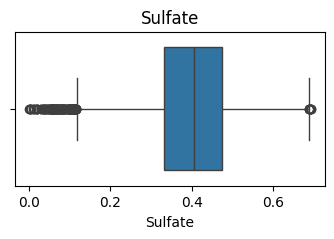

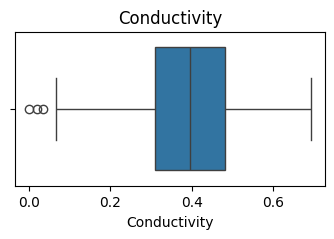

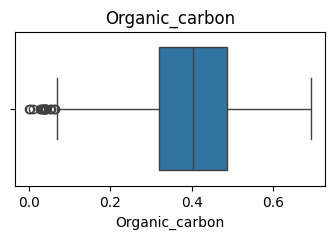

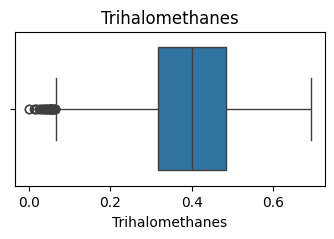

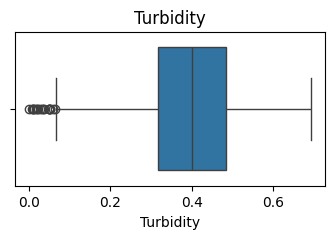

In [30]:
for col in df.columns[:-1]:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


**Train–Test Split**

In [31]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


**XGBoost Model**

In [32]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)


**Training & Prediction**

In [33]:
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got [0.         0.69314718]

**Evaluation**

In [34]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Precision:", precision_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


NameError: name 'y_pred_xgb' is not defined

In [35]:
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


NameError: name 'y_pred_xgb' is not defined

**LightGBM Model
Model Initialization**

In [36]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)


**Training & Prediction**

In [37]:
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:,1]


ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

**Evaluation**

In [38]:
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("LightGBM Precision:", precision_score(y_test, y_pred_lgbm))
print("LightGBM ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))


NameError: name 'y_pred_lgbm' is not defined

**Confusion Matrix**

In [39]:
cm = confusion_matrix(y_test, y_pred_lgbm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


NameError: name 'y_pred_lgbm' is not defined

**ROC Curve Comparison**

In [40]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)

plt.figure(figsize=(6,5))
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot(fpr_lgbm, tpr_lgbm, label="LightGBM")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


NameError: name 'y_prob_xgb' is not defined

**Final Comparison Table**

In [ ]:
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgbm)
    ]
})

results


,Model,Accuracy,Precision,ROC-AUC
0,XGBoost,0.652085,0.604061,0.645788
1,LightGBM,0.649034,0.579167,0.639060



Perform hyperparameter tuning for the XGBoost model using GridSearchCV or RandomizedSearchCV to optimize parameters such as 'n_estimators', 'max_depth', 'learning_rate', 'subsample', and 'colsample_bytree' with 'roc_auc' as the scoring metric. Subsequently, retrain the XGBoost model with the optimal hyperparameters, evaluate its performance using accuracy, precision, and ROC-AUC scores, and visualize its confusion matrix. Next, perform hyperparameter tuning for the LightGBM model using GridSearchCV or RandomizedSearchCV to optimize parameters such as 'n_estimators', 'learning_rate', 'max_depth', and 'num_leaves' with 'roc_auc' as the scoring metric. Afterward, retrain the LightGBM model with its optimal hyperparameters, evaluate its performance using accuracy, precision, and ROC-AUC scores, and visualize its confusion matrix. Finally, compare the performance metrics of the tuned XGBoost and LightGBM models, update the ROC curve comparison plot to include the tuned models, generate a final comparison table, and summarize the improvements in model accuracy after hyperparameter tuning.

**Hyperparameter Tuning for XGBoost**

Perform hyperparameter tuning for the XGBoost model using techniques like GridSearchCV or RandomizedSearchCV to optimize parameters such as 'n_estimators', 'max_depth', 'learning_rate', 'subsample', and 'colsample_bytree'. The optimal parameters will be chosen based on a suitable scoring metric, such as 'roc_auc'.

Reasoning: The subtask requires performing hyperparameter tuning for the XGBoost model using GridSearchCV. I need to import GridSearchCV, define the parameter grid, initialize the XGBClassifier, create and fit the GridSearchCV object, and then print the best parameters and best score.



In [ ]:


#  Define a dictionary named param_grid_xgb
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# 3. Initialize an XGBClassifier
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

#  Create a GridSearchCV object
grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1  # Use all available cores
)

# Fit grid_search_xgb to your training data
grid_search_xgb.fit(X_train, y_train)


print("Best parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best ROC-AUC score for XGBoost:", grid_search_xgb.best_score_)

XGBoost Accuracy: 0.6934554059504501
Best parameters for XGBoost: {'colsample_bytree': 0.9, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7}
Best ROC-AUC score for XGBoost: 0.6934554059504501


Evaluate Tuned XGBoost Model
Subtask:
Retrain the XGBoost model with the best hyperparameters found during tuning and evaluate its performance using accuracy, precision, and ROC-AUC scores on the test set. Also, visualize the confusion matrix for the tuned model.
Reasoning: To evaluate the tuned XGBoost model, I need to initialize a new XGBoost classifier with the best parameters found during GridSearchCV, train it, make predictions, and then calculate the accuracy, precision, and ROC-AUC scores, finally visualizing the confusion matrix.

Tuned XGBoost Accuracy: 0.6744659206510681
Tuned XGBoost Precision: 0.7787610619469026
Tuned XGBoost ROC-AUC: 0.6652001740644039


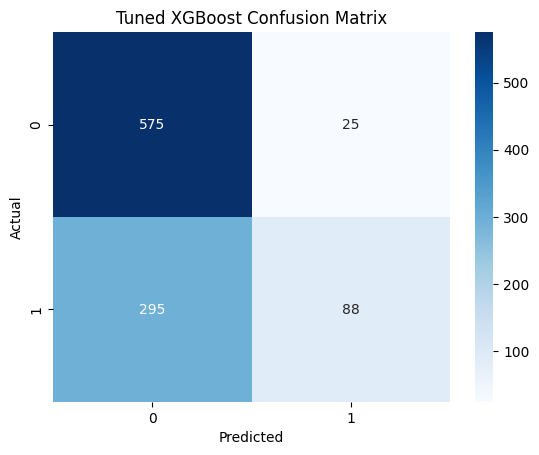

In [ ]:
tuned_xgb_model = XGBClassifier(
    **grid_search_xgb.best_params_,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

tuned_xgb_model.fit(X_train, y_train)
y_pred_tuned_xgb = tuned_xgb_model.predict(X_test)
y_prob_tuned_xgb = tuned_xgb_model.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_tuned_xgb))
print("Tuned XGBoost Precision:", precision_score(y_test, y_pred_tuned_xgb))
print("Tuned XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_tuned_xgb))

cm_tuned_xgb = confusion_matrix(y_test, y_pred_tuned_xgb)
sns.heatmap(cm_tuned_xgb, annot=True, fmt="d", cmap="Blues")
plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Reasoning: To perform hyperparameter tuning for the LightGBM model, I need to define a parameter grid for the LightGBM classifier and then use GridSearchCV to find the best combination of parameters based on the 'roc_auc' scoring metric.

In [ ]:
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 5, 10],
    'num_leaves': [20, 31, 50]
}

lgbm = LGBMClassifier(random_state=42)

grid_search_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid_lgbm,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_search_lgbm.fit(X_train, y_train)

print("Best parameters for LightGBM:", grid_search_lgbm.best_params_)
print("Best ROC-AUC score for LightGBM:", grid_search_lgbm.best_score_)

[LightGBM] [Info] Number of positive: 895, number of negative: 1398
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2293, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390318 -> initscore=-0.445974
[LightGBM] [Info] Start training from score -0.445974
Best parameters for LightGBM: {'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 50}
Best ROC-AUC score for LightGBM: 0.6846161184483406


**Reasoning**:
To evaluate the tuned LightGBM model, I need to initialize a new LightGBM classifier with the best parameters found during GridSearchCV, train it, make predictions, and then calculate the accuracy, precision, and ROC-AUC scores, finally visualizing the confusion matrix.



[LightGBM] [Info] Number of positive: 895, number of negative: 1398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2293, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390318 -> initscore=-0.445974
[LightGBM] [Info] Start training from score -0.445974
Tuned LightGBM Accuracy: 0.6632756866734486
Tuned LightGBM Precision: 0.6477272727272727
Tuned LightGBM ROC-AUC: 0.664556135770235


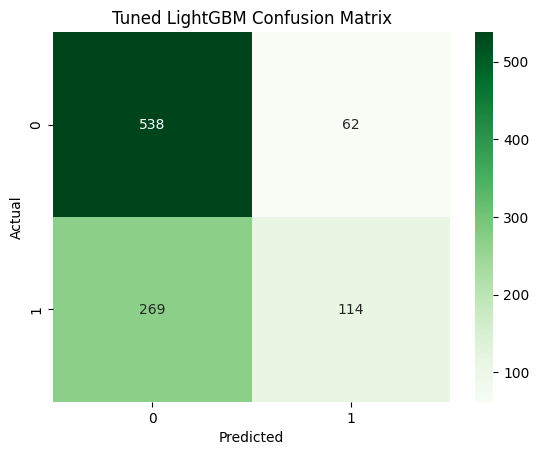

In [ ]:
tuned_lgbm_model = LGBMClassifier(
    **grid_search_lgbm.best_params_,
    random_state=42
)

tuned_lgbm_model.fit(X_train, y_train)
y_pred_tuned_lgbm = tuned_lgbm_model.predict(X_test)
y_prob_tuned_lgbm = tuned_lgbm_model.predict_proba(X_test)[:, 1]

print("Tuned LightGBM Accuracy:", accuracy_score(y_test, y_pred_tuned_lgbm))
print("Tuned LightGBM Precision:", precision_score(y_test, y_pred_tuned_lgbm))
print("Tuned LightGBM ROC-AUC:", roc_auc_score(y_test, y_prob_tuned_lgbm))

cm_tuned_lgbm = confusion_matrix(y_test, y_pred_tuned_lgbm)
sns.heatmap(cm_tuned_lgbm, annot=True, fmt="d", cmap="Greens")
plt.title("Tuned LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Reasoning**:
I need to generate ROC curves for the tuned XGBoost and LightGBM models to compare their performance visually. This involves calculating the False Positive Rate (FPR) and True Positive Rate (TPR) for both tuned models using their predicted probabilities.



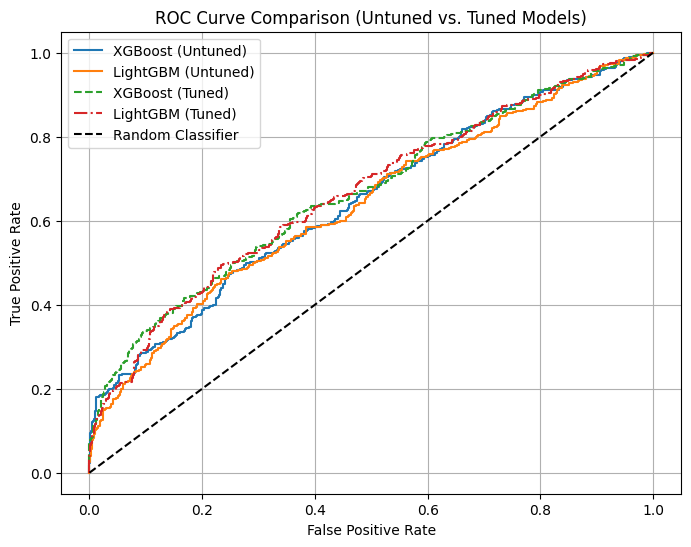

In [ ]:
fpr_tuned_xgb, tpr_tuned_xgb, _ = roc_curve(y_test, y_prob_tuned_xgb)
fpr_tuned_lgbm, tpr_tuned_lgbm, _ = roc_curve(y_test, y_prob_tuned_lgbm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (Untuned)')
plt.plot(fpr_lgbm, tpr_lgbm, label='LightGBM (Untuned)')
plt.plot(fpr_tuned_xgb, tpr_tuned_xgb, label='XGBoost (Tuned)', linestyle='--')
plt.plot(fpr_tuned_lgbm, tpr_tuned_lgbm, label='LightGBM (Tuned)', linestyle='-.')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Untuned vs. Tuned Models)')
plt.legend()
plt.grid(True)
plt.show()

**Reasoning**:
To provide a comprehensive comparison, I will create a new DataFrame that includes the performance metrics for both untuned and tuned XGBoost and LightGBM models.



In [ ]:
results_tuned = pd.DataFrame({
    "Model": [
        "XGBoost (Untuned)", "LightGBM (Untuned)",
        "XGBoost (Tuned)", "LightGBM (Tuned)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_tuned_xgb),
        accuracy_score(y_test, y_pred_tuned_lgbm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_tuned_xgb),
        precision_score(y_test, y_pred_tuned_lgbm)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgbm),
        roc_auc_score(y_test, y_prob_tuned_xgb),
        roc_auc_score(y_test, y_prob_tuned_lgbm)
    ]
})

print(results_tuned)


                Model  Accuracy  Precision   ROC-AUC
0   XGBoost (Untuned)  0.652085   0.604061  0.645788
1  LightGBM (Untuned)  0.649034   0.579167  0.639060
2     XGBoost (Tuned)  0.674466   0.778761  0.665200
3    LightGBM (Tuned)  0.663276   0.647727  0.664556
